# Study 1 — Confirmation Bias in LLMs: Cue Effects on Probability Distributions

Baseline = `memory_only` condition (model re-reads its prior, no cue).
ΔP = post-cue distribution − memory_only distribution.

Replicates:
- **Figure 1 (6-panel):** ΔP bar charts by condition (Pull / Oppose / Reinforce × Left / Right)
- **Figure 2 (2-panel):** Oppose cue effects by distance — ΔP(prior) and ΔP(cue target)

In [57]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

# ── Publication-quality settings (top-tier CS conference) ──
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7.5,
    "figure.dpi": 300,
    "figure.facecolor": "white",
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "lines.linewidth": 1.2,
    "lines.markersize": 4,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ── Load data ──
study1_path = "/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study1/phi4_study1_full_results.jsonl"

with open(study1_path) as f:
    study1_rows = [json.loads(line) for line in f if line.strip()]

# ── Build memory_only baseline lookup ──
memory_only_lookup = {}
for r in study1_rows:
    if r["metadata"]["cue_direction"] == "none":
        qid = r["metadata"]["qid"]
        probs = {int(k): float(v) for k, v in r["response"]["probs"].items()}
        mode = int(r["metadata"]["prev_answer"])
        memory_only_lookup[qid] = {"probs": probs, "mode": mode}

# ── Filter cued trials ──
cued_rows = [r for r in study1_rows
             if r["metadata"]["cue_direction"] not in ("none", "weak_reinforce")]

print(f"Study1 total rows: {len(study1_rows)}")
print(f"Memory-only baselines: {len(memory_only_lookup)}")
print(f"Cued rows (excl none/weak_reinforce): {len(cued_rows)}")

dirs = Counter(r["metadata"]["cue_direction"] for r in cued_rows)
for d, n in sorted(dirs.items()):
    print(f"  {d}: {n}")


Study1 total rows: 546
Memory-only baselines: 78
Cued rows (excl none/weak_reinforce): 384
  oppose_left: 128
  oppose_right: 140
  pull_left: 33
  pull_right: 33
  reinforce_left: 38
  reinforce_right: 12


In [58]:
# ── Compute ΔP = post_cue_prob - memory_only_prob at each position (1-7) ──
records = []
for r in cued_rows:
    m = r["metadata"]
    qid = m["qid"]
    bl = memory_only_lookup.get(qid)
    if not bl:
        continue

    prev_answer = int(m["prev_answer"])
    cue_target = int(m["cue_target"])
    cue_dist = int(m["cue_distance"])
    direction = m["cue_direction"]

    # Memory-only baseline and post-cue distributions
    bl_probs = np.array([bl["probs"].get(i, 0) for i in range(1, 8)])
    post_probs = np.array([float(r["response"]["probs"].get(str(i), 0))
                           for i in range(1, 8)])
    delta_p = post_probs - bl_probs

    records.append({
        "qid": qid,
        "prev_answer": prev_answer,
        "cue_target": cue_target,
        "cue_distance": cue_dist,
        "direction": direction,
        "bl_probs": bl_probs,
        "post_probs": post_probs,
        "delta_p": delta_p,  # length-7 array, positions 1-7
        "delta_p_prior": post_probs[prev_answer - 1] - bl_probs[prev_answer - 1],
        "delta_p_cue": post_probs[cue_target - 1] - bl_probs[cue_target - 1],
    })

print(f"Records: {len(records)}")

Records: 384


## Figure 1: Confirmation Bias — ΔP Distribution Shifts by Condition

6-panel layout: Pull / Oppose / Reinforce × Left / Right

ΔP = post-cue − memory_only baseline

## Figure 2: Oppose (Counter-Attitudinal) Cue Effects by Distance

Panel A: ΔP(prior position) — how much the model loosens grip on its prior.
Panel B: ΔP(cue target position) — how much the model moves toward the cue.

In [52]:
# ── Oppose cue effects by distance ──
oppose = [r for r in records if r["direction"] in ("oppose_left", "oppose_right")]
print(f"All oppose trials: {len(oppose)}")

# Group by cue_distance
dist_groups = defaultdict(list)
for r in oppose:
    dist_groups[r["cue_distance"]].append(r)

distances = sorted(dist_groups.keys())
for d in distances:
    print(f"  distance={d}: n={len(dist_groups[d])}")

# Compute mean and 95% CI
mean_dp_prior = []
ci_dp_prior = []
mean_dp_cue = []
ci_dp_cue = []
ns = []

for d in distances:
    subset = dist_groups[d]
    n = len(subset)
    ns.append(n)

    dp_prior = np.array([r["delta_p_prior"] for r in subset])
    dp_cue = np.array([r["delta_p_cue"] for r in subset])

    mean_dp_prior.append(dp_prior.mean())
    ci_dp_prior.append(1.96 * dp_prior.std(ddof=1) / np.sqrt(n))
    mean_dp_cue.append(dp_cue.mean())
    ci_dp_cue.append(1.96 * dp_cue.std(ddof=1) / np.sqrt(n))

mean_dp_prior = np.array(mean_dp_prior)
ci_dp_prior = np.array(ci_dp_prior)
mean_dp_cue = np.array(mean_dp_cue)
ci_dp_cue = np.array(ci_dp_cue)
distances = np.array(distances)

All oppose trials: 268
  distance=1: n=7
  distance=2: n=43
  distance=3: n=67
  distance=4: n=67
  distance=5: n=60
  distance=6: n=24


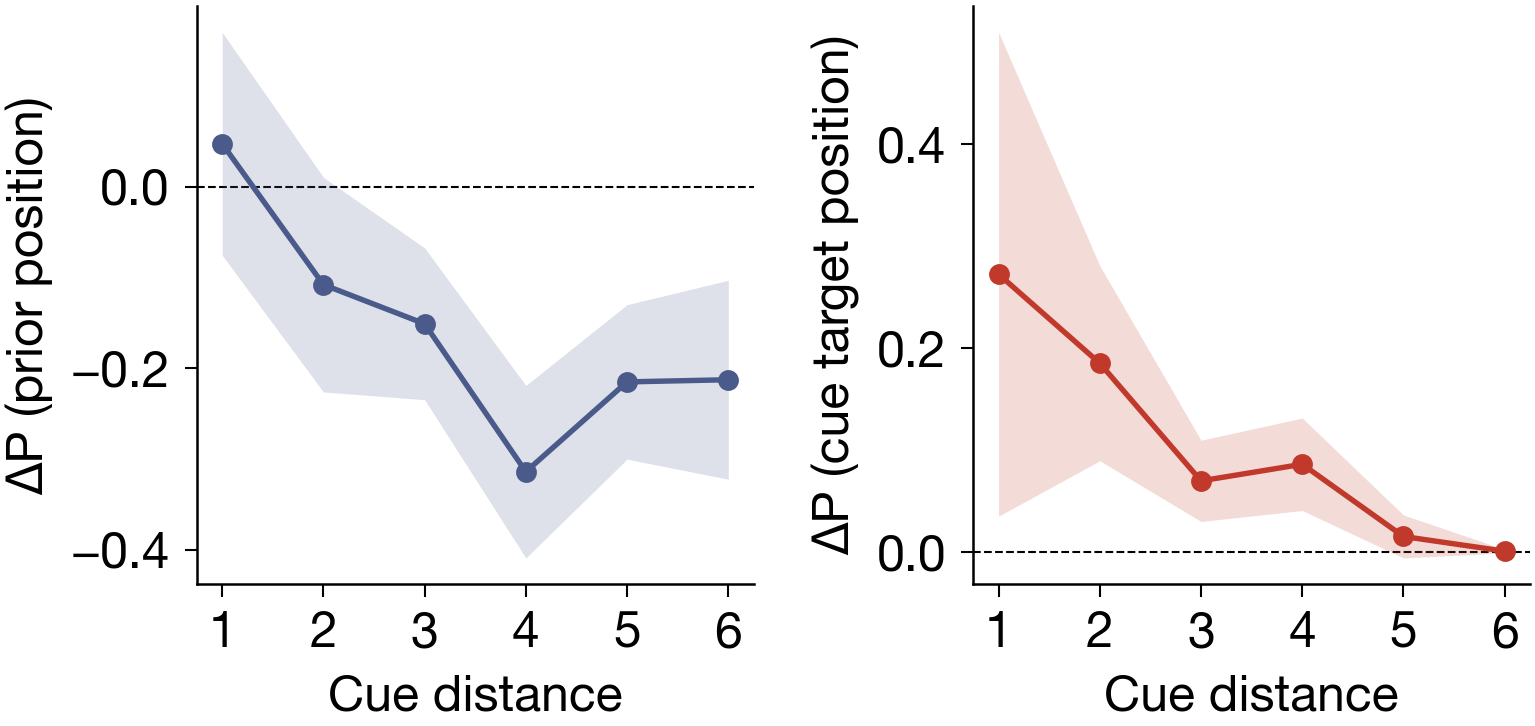

In [63]:
# ── Figure 2: Oppose cue effects by distance (conference style) ──
import matplotlib as mpl
mpl.rcParams["text.usetex"] = False

mpl.rcParams.update({
    "font.size": 14,              # main text size
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.titlesize": 14,
})

C_PRIOR = "#4A5A8A"
C_CUE = "#C0392B"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5.5, 2.8))

# ── Panel (a): ΔP(prior) ──
ax1.plot(distances, mean_dp_prior, "o-", color=C_PRIOR, markersize=4,
         linewidth=1.3, zorder=3)
# Shaded CI band instead of error bars
ax1.fill_between(distances, mean_dp_prior - ci_dp_prior, mean_dp_prior + ci_dp_prior,
                 color=C_PRIOR, alpha=0.18, linewidth=0, zorder=2)

ax1.axhline(0, color="black", linewidth=0.5, linestyle="--", zorder=1)
ax1.set_xlabel("Cue distance")
ax1.set_ylabel("ΔP (prior position)")
ax1.set_xticks(distances)

# ── Panel (b): ΔP(cue target) ──
ax2.plot(distances, mean_dp_cue, "o-", color=C_CUE, markersize=4,
         linewidth=1.3, zorder=3)
ax2.fill_between(distances, mean_dp_cue - ci_dp_cue, mean_dp_cue + ci_dp_cue,
                 color=C_CUE, alpha=0.18, linewidth=0, zorder=2)

ax2.axhline(0, color="black", linewidth=0.5, linestyle="--", zorder=1)
ax2.set_xlabel("Cue distance")
ax2.set_ylabel("ΔP (cue target position)")
ax2.set_xticks(distances)


plt.tight_layout(w_pad=1.0)
plt.savefig("fig2_study1_oppose_distance_phi4.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig("fig2_study1_oppose_distance_phi4.pdf", bbox_inches="tight", facecolor="white")
plt.show()


In [20]:
# ── Summary statistics ──
print("=" * 65)
print("STUDY 1 — CONFIRMATION BIAS SUMMARY")
print("Baseline: memory_only condition (model re-reads prior, no cue)")
print("=" * 65)

for direction in ["pull_left", "pull_right", "oppose_left", "oppose_right",
                  "reinforce_left", "reinforce_right"]:
    subset = [r for r in records if r["direction"] == direction]
    if not subset:
        continue
    n = len(subset)
    dp_prior = np.array([r["delta_p_prior"] for r in subset])
    dp_cue = np.array([r["delta_p_cue"] for r in subset])

    print(f"\n{direction} (n={n}):")
    print(f"  Mean \u0394P(prior):      {dp_prior.mean():+.4f} \u00b1 {dp_prior.std(ddof=1)/np.sqrt(n):.4f}")
    print(f"  Mean \u0394P(cue target): {dp_cue.mean():+.4f} \u00b1 {dp_cue.std(ddof=1)/np.sqrt(n):.4f}")

print()
print("Oppose by distance:")
for d in sorted(dist_groups.keys()):
    subset = dist_groups[d]
    n = len(subset)
    dp_p = np.mean([r["delta_p_prior"] for r in subset])
    dp_c = np.mean([r["delta_p_cue"] for r in subset])
    print(f"  distance={d} (n={n:>3d}): \u0394P(prior)={dp_p:+.4f}, \u0394P(cue)={dp_c:+.4f}")

STUDY 1 — CONFIRMATION BIAS SUMMARY
Baseline: memory_only condition (model re-reads prior, no cue)

oppose_left (n=168):
  Mean ΔP(prior):      -0.1464 ± 0.0182
  Mean ΔP(cue target): +0.0656 ± 0.0101

oppose_right (n=144):
  Mean ΔP(prior):      -0.4360 ± 0.0225
  Mean ΔP(cue target): +0.1873 ± 0.0164

reinforce_left (n=48):
  Mean ΔP(prior):      -0.0457 ± 0.0236
  Mean ΔP(cue target): +0.0393 ± 0.0139

reinforce_right (n=63):
  Mean ΔP(prior):      -0.0051 ± 0.0268
  Mean ΔP(cue target): +0.0696 ± 0.0172

Oppose by distance:
  distance=1 (n= 48): ΔP(prior)=-0.0912, ΔP(cue)=+0.1404
  distance=2 (n= 63): ΔP(prior)=-0.1902, ΔP(cue)=+0.1517
  distance=3 (n= 78): ΔP(prior)=-0.3128, ΔP(cue)=+0.1401
  distance=4 (n= 78): ΔP(prior)=-0.3189, ΔP(cue)=+0.0921
  distance=5 (n= 30): ΔP(prior)=-0.4460, ΔP(cue)=+0.0953
  distance=6 (n= 15): ΔP(prior)=-0.5564, ΔP(cue)=+0.0485
